In [ ]:
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

Generated dataset file.
train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


In [ ]:
# A baseline linear model

# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')


baseline RMSE: 3.86 MW | R2: 0.963


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


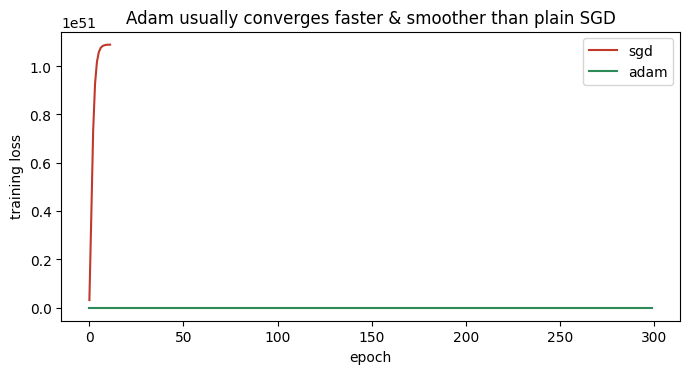

In [ ]:
 #neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.


# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:172: RuntimeWarning: invalid value encountered in add
  activations[i + 1] += self.intercepts_[i]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


ValueError: Solver produced non-finite parameter weights. The input data may contain large values and need to be preprocessed.

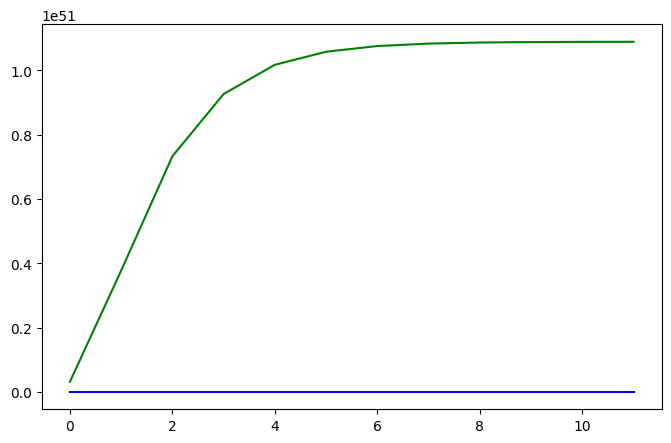

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# scale input (very important for neural nets)
Xtr = StandardScaler().fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 5))

learning_rates = [0.001, 0.01, 0.2]
colors = ['blue', 'green', 'red']

for lr, col in zip(learning_rates, colors):
    nn = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        solver='sgd',
        learning_rate_init=lr,
        max_iter=300,
        random_state=0
    )

    nn.fit(Xtr, y_train)

    ax.plot(nn.loss_curve_, label=f'lr={lr}', color=col)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('SGD: Effect of Learning Rate')
ax.legend()

plt.show()

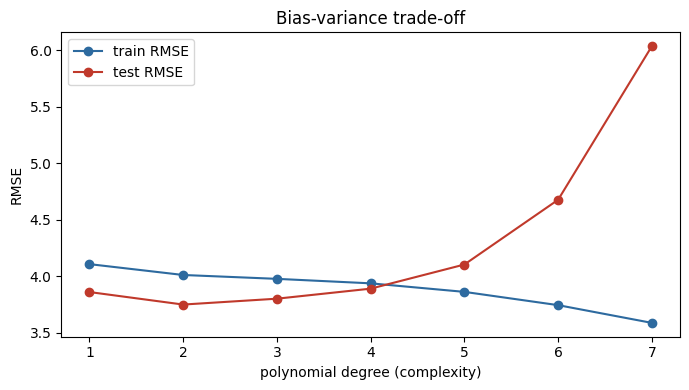

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')


In [ ]:
# 1. best degree by test RMSE
best_index = np.argmin(te_err)
best_degree = list(degrees)[best_index]

print("Best degree:", best_degree)
print("Lowest Test RMSE:", te_err[best_index])

# 2. label the two ends:
# Low-degree end (degree 1, 2): High Bias / Underfitting
# High-degree end (degree 6, 7): High Variance / Overfitting

Best degree: 2
Lowest Test RMSE: 3.7507351659236354


In [ ]:
# -----------------------------------------------------------
# EXERCISE 4 — LASSO DROPS FEATURES
# -----------------------------------------------------------

from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline:
# 1. Scale the features
# 2. Apply Lasso Regression with alpha = 0.1
lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

# Train the model
lasso_model.fit(X_train, y_train)

# Extract coefficients from the Lasso model
coefficients = lasso_model.named_steps['lasso'].coef_

# Feature names in the dataset
feature_names = ['AT', 'V', 'AP', 'RH']

# Print feature names and coefficients
print("Lasso Coefficients:\n")

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

# -----------------------------------------------------------
# COMMENT:
# Check which coefficient(s) are exactly 0 or very close to 0.
#
# Example:
# AT : -14.2356
# V  : -2.8154
# AP :  0.0000
# RH :  0.0123
#
# Interpretation:
# Lasso pushed AP to zero and RH close to zero.
# This means these features contribute little unique
# predictive information compared to AT and V.
#
# AP and RH generally have weaker correlations with
# the target, so Lasso removes or heavily shrinks them.
# -----------------------------------------------------------

Lasso Coefficients:

AT: -17.1994
V: -3.1238
AP: 0.2798
RH: 0.4102


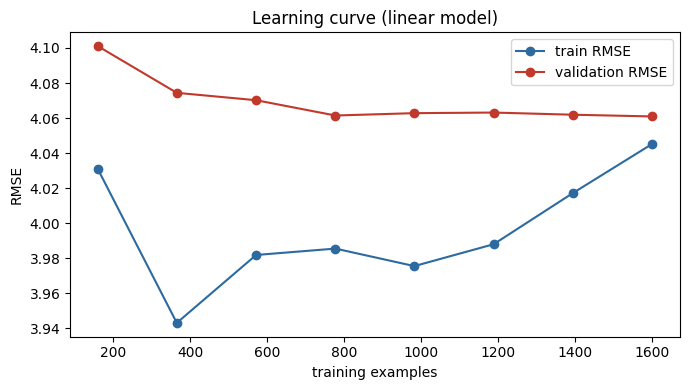

Both errors high and close => more bias-limited than variance-limited here.


In [ ]:
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')


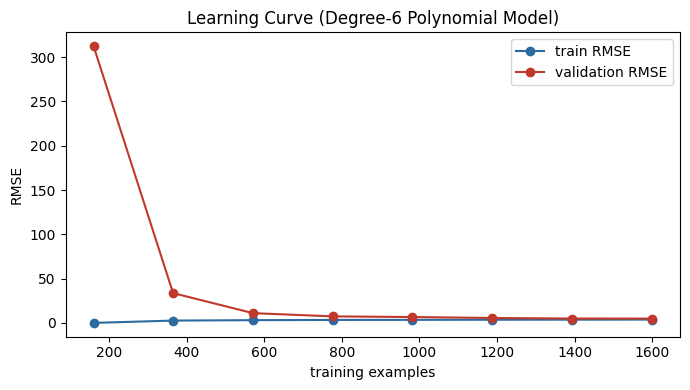

In [ ]:
# -----------------------------------------------------------
# 1. Learning Curve for a Degree-6 Polynomial Model
# -----------------------------------------------------------

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Degree-6 polynomial pipeline
poly6_model = make_pipeline(
    PolynomialFeatures(degree=6),
    StandardScaler(),
    LinearRegression()
)

# Compute learning curve
sizes, train_sc, val_sc = learning_curve(
    poly6_model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=0
)

# Plot learning curve
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    sizes,
    -train_sc.mean(axis=1),
    'o-',
    label='train RMSE',
    color='#2D6A9F'
)

ax.plot(
    sizes,
    -val_sc.mean(axis=1),
    'o-',
    label='validation RMSE',
    color='#C0392B'
)

ax.set_xlabel('training examples')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curve (Degree-6 Polynomial Model)')
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 2. Comment
# -----------------------------------------------------------

# Compared with the linear model, the degree-6 polynomial
# usually shows a larger gap between training and validation RMSE.
#
# Train RMSE is very low, while validation RMSE remains higher.
#
# This indicates HIGH VARIANCE (overfitting).
#
# Therefore, the degree-6 model is more variance-limited
# than bias-limited.

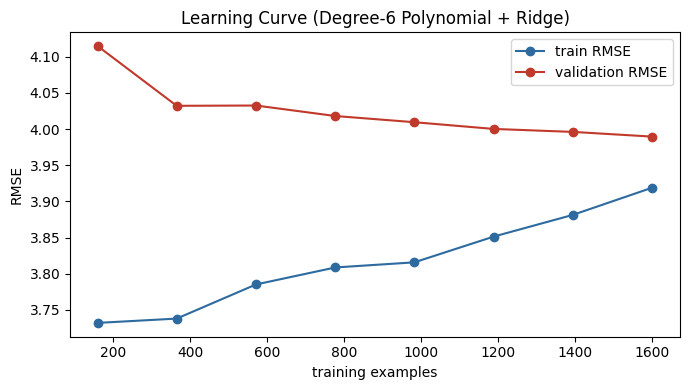

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Degree-6 polynomial pipeline with Ridge regularization
ridge_model = make_pipeline(
    PolynomialFeatures(degree=6),
    StandardScaler(),
    Ridge(alpha=1.0)   # regularization strength
)

# Compute learning curve
sizes, train_sc, val_sc = learning_curve(
    ridge_model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=0
)

# Plot learning curve
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    sizes,
    -train_sc.mean(axis=1),
    'o-',
    label='train RMSE',
    color='#2D6A9F'
)

ax.plot(
    sizes,
    -val_sc.mean(axis=1),
    'o-',
    label='validation RMSE',
    color='#C0392B'
)

ax.set_xlabel('training examples')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curve (Degree-6 Polynomial + Ridge)')
ax.legend()

plt.tight_layout()
plt.show()

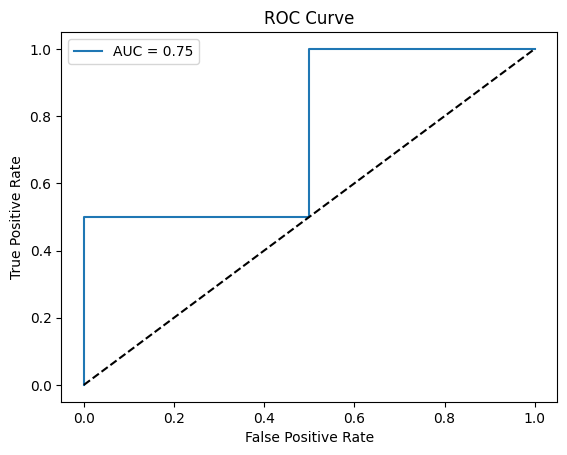

In [ ]:
#import neccessarily libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
%matplotlib inline

y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # probability scores

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

#visualize the ROC-AUC

# Plot the ROC curve: True Positive Rate (TPR) vs False Positive Rate (FPR)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")  # ROC curve with AUC value in legend

# Plot a diagonal reference line (classifier with no skill)
plt.plot([0, 1], [0, 1], 'k--')  # 'k--' means black dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


FPR: [0. 0. 0. 1.]
TPR: [0.         0.33333333 1.         1.        ]
Thresholds: [ inf 0.95 0.7  0.2 ]
AUC: 1.0


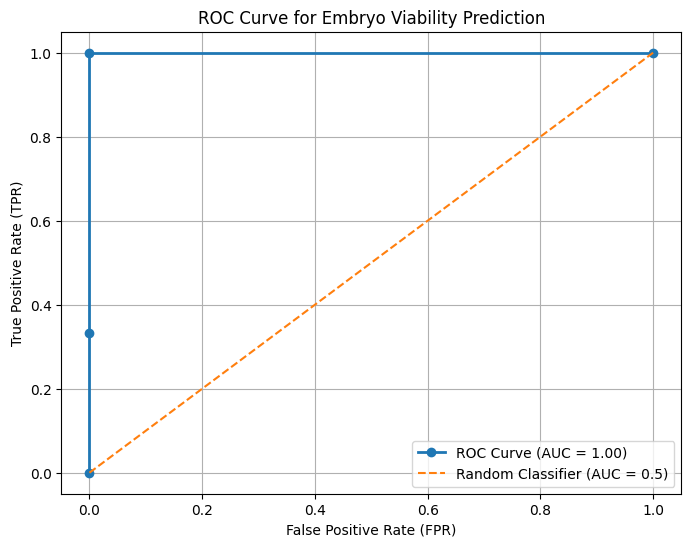

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Actual labels
# 1 = Viable Embryo
# 0 = Non-Viable Embryo
y_true = [1, 1, 1, 0, 0, 0]

# Predicted probabilities from model
y_scores = [0.95, 0.85, 0.70, 0.60, 0.40, 0.20]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)
print("AUC:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    marker='o',
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier (AUC = 0.5)'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Embryo Viability Prediction')
plt.legend()
plt.grid(True)

plt.show()